# Chapter 7 — Division of Labor
**Modeling Social Behavior** | Smaldino

---

## 📚 What This Model Is About

This is a fundamentally different model from the three coordination models before it. The previous models asked: *which norm wins when agents prefer to match each other?* This model asks:

> What happens when two groups interact economically — trading, specializing, dividing labor — and one norm entitles its holders to a **larger share of the surplus**?

The real-world referent is **social stratification**: norms that determine who gets the "high" role (more of the surplus) and who gets the "low" role (less of the surplus) in an economic exchange. Think of:
- Norms around who is the employer vs. employee
- Caste systems that determine who does high-status vs. low-status work
- Gender norms about who manages household resources
- Trade norms that favor one group's merchants over another's

The model is based on **Henrich & Boyd (2008)**, who showed that such stratifying norms can spread and stabilize even when they're collectively inefficient — because the group that benefits from the norm will imitate and spread it.

---

## 🔄 The Core Scenario

There are two groups (A and B) and two norms:
- **Norm 1** = claim the **high share** of any economic surplus
- **Norm 2** = accept the **low share** of any economic surplus

When two agents interact and produce a surplus together:
- If both have **Norm 1**: conflict — one takes the high share, one takes the low share (we assume Norm 1 wins the conflict, so Norm 1 holders always get `high_share` when paired together — see payoff details)
- If both have **Norm 2**: cooperation but low total — both get the low share
- If a **Norm 1 meets Norm 2**: Norm 1 takes the high share, Norm 2 gets the low share
- Interactions happen **both within and between groups**

**The key asymmetry:** Norm 1 holders always claim the high share regardless of who they're interacting with. Norm 2 holders always accept the low share.

---

## 🧮 The Payoff Structure (Read Carefully — This Is New)

There is a surplus `S` generated from each interaction. It is divided as:
- **High share**: `norm1_share × S` → goes to Norm 1 agent
- **Low share**: `(1 - norm1_share) × S` → goes to Norm 2 agent

Each agent interacts with:
- Their **own group** with probability `1 - prob_outgroup_interaction`
- The **other group** with probability `prob_outgroup_interaction`

Let $p_{in}$ = Norm 1 frequency in own group, $p_{out}$ = Norm 1 frequency in other group.

Let $q$ = `prob_outgroup_interaction`, $s_H$ = high share = `norm1_share × S`, $s_L$ = low share = `(1 - norm1_share) × S`.

**Norm 1 agent's expected payoff:**

When paired with anyone, a Norm 1 agent always gets the high share (baseline 1 + $s_H$) when meeting a Norm 2 agent, and gets the high share (baseline 1 + $s_H$... actually just baseline 1 per the code logic) when meeting a Norm 1 agent since both claim high, no surplus is created productively — the baseline 1 applies.

Reading the code precisely:
$$\pi_1 = q \cdot [(1-p_{out})(1+s_H) + p_{out}\cdot 1] + (1-q)\cdot[(1-p_{in})(1+s_H) + p_{in}\cdot 1]$$

**Norm 2 agent's expected payoff:**
$$\pi_2 = q \cdot [(1-p_{out})\cdot 1 + p_{out}(1+s_L)] + (1-q)\cdot[(1-p_{in})\cdot 1 + p_{in}(1+s_L)]$$

**Interpretation:**
- Norm 1 agents earn the high surplus **only when meeting a Norm 2 agent** (someone who will yield the high share). When two Norm 1 agents meet, no surplus sharing happens (both get baseline 1).
- Norm 2 agents earn the low surplus **only when meeting a Norm 1 agent** (someone who will take the high share). When two Norm 2 agents meet, no surplus sharing happens (both get baseline 1).
- This means the norms are **complementary** — a Norm 1 agent and a Norm 2 agent together generate traded surplus; two same-norm agents don't.

---

## 💡 The Two Separate Probabilities

This model introduces a crucial distinction between two different types of cross-group contact:

| Parameter | What it controls |
|---|---|
| `prob_outgroup_interaction` | Who you **trade with / interact economically** (affects payoffs) |
| `prob_outgroup_observation` | Who you **observe and potentially copy** (affects norm evolution) |

These can be set independently. A group might trade heavily with another group but rarely copy their norms — or vice versa.

---

## 🎯 The Key Dynamics

**Why does Norm 1 spread?**
- Norm 1 holders do well when they frequently meet Norm 2 holders (they extract the high share).
- If Group A is mostly Norm 1 and Group B is mostly Norm 2, and the groups interact economically, Group A earns high surpluses from those interactions.
- Group B agents observe Group A's high payoffs and copy Norm 1 — but this backfires: if Group B also becomes Norm 1, both groups now contain mostly Norm 1 agents who can't extract surplus from each other.

**The `norm1_share` parameter controls fairness:**
- `norm1_share = 0.5` → equal split → no stratification incentive → both norms yield similar payoffs
- `norm1_share > 0.5` → Norm 1 takes more → stratification → Norm 1 spreads through the population
- `norm1_share = 1.0` → Norm 1 takes everything → extreme stratification

---

## 🔢 Variable Reference

| Variable | Type | Description |
|---|---|---|
| `N` | Global | Total agents (N//2 per group) |
| `init_norm1_A` | Global (param) | Initial Norm 1 freq in Group A |
| `init_norm1_B` | Global (param) | Initial Norm 1 freq in Group B |
| `surplus_benefit` | Global (param) | Total surplus `S` generated per interaction |
| `norm1_share` | Global (param) | Fraction of surplus going to Norm 1 holder (0.5 = fair, >0.5 = unfair) |
| `prob_outgroup_interaction` | Global (param) | Probability of interacting *economically* with the other group |
| `prob_outgroup_observation` | Global (param) | Probability of *observing/copying* from the other group |
| `agent.norm` | Agent | Integer: 1 = claim high share, 2 = accept low share |
| `agent.group` | Agent | Integer: 0 = Group A, 1 = Group B |
| `agent.payoff` | Agent | Float: expected payoff this tick |
| `p_in` | Local | Norm 1 frequency in agent's own group |
| `p_out` | Local | Norm 1 frequency in the other group |
| `pay_high` | Local | High share value = norm1_share × surplus_benefit |
| `pay_low` | Local | Low share value = (1 - norm1_share) × surplus_benefit |

---

## 📦 Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import random

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
## 🤖 Agent Class

In [2]:
class Agent:
    """
    Represents one individual in the division of labor model.

    Agent-level attributes:
    -----------------------
    norm   : int   — which norm the agent holds:
                     1 = claim the HIGH share of surplus
                     2 = accept the LOW share of surplus
    group  : int   — which group the agent belongs to (0 = Group A, 1 = Group B)
    payoff : float — expected payoff this tick (set by calculate_payoffs)
    """

    def __init__(self, norm, group):
        self.norm   = norm    # int: 1 or 2
        self.group  = group   # int: 0 or 1
        self.payoff = 0.0     # float: updated each tick

---
## ⚙️ Model Functions

In [3]:
def setup(N, init_norm1_A, init_norm1_B):
    """
    Create the two-group population with different starting norm frequencies.

    Parameters (global):
    --------------------
    N            : int   — total agents; N//2 go to each group
    init_norm1_A : float — initial Norm 1 frequency in Group A
    init_norm1_B : float — initial Norm 1 frequency in Group B

    Returns:
    --------
    agents : list of Agent
    """
    agents = []
    n_per_group = N // 2  # local: equal group sizes

    for _ in range(n_per_group):
        norm = 1 if random.random() < init_norm1_A else 2
        agents.append(Agent(norm=norm, group=0))

    for _ in range(n_per_group):
        norm = 1 if random.random() < init_norm1_B else 2
        agents.append(Agent(norm=norm, group=1))

    return agents


def calculate_payoffs(agents, surplus_benefit, norm1_share, prob_outgroup_interaction):
    """
    Calculate expected payoffs for every agent.

    KEY DIFFERENCE FROM PREVIOUS MODELS:
    Payoffs depend on BOTH within-group and cross-group norm frequencies,
    weighted by how often agents interact within vs. across groups.

    Surplus division:
    -----------------
    pay_high = norm1_share * surplus_benefit     (what Norm 1 agents earn in mixed pair)
    pay_low  = (1 - norm1_share) * surplus_benefit  (what Norm 2 agents earn in mixed pair)

    Payoff formulas:
    ----------------
    π₁ = q * [(1-p_out)*(1+pay_high) + p_out*1]
           + (1-q) * [(1-p_in)*(1+pay_high) + p_in*1]

    π₂ = q * [(1-p_out)*1 + p_out*(1+pay_low)]
           + (1-q) * [(1-p_in)*1 + p_in*(1+pay_low)]

    where:
    - q = prob_outgroup_interaction
    - p_in  = Norm 1 frequency in the agent's own group
    - p_out = Norm 1 frequency in the OTHER group

    Note: Norm 1 earns the surplus only from Norm 2 partners (who yield).
          Norm 2 earns the surplus only from Norm 1 partners (who take the high share).
          Same-norm pairings produce no surplus sharing — both get baseline 1.

    Parameters (all global-level):
    ------------------------------
    agents                    : list of Agent
    surplus_benefit           : float — total surplus S per interaction
    norm1_share               : float — fraction of S going to Norm 1 holder
    prob_outgroup_interaction  : float — q: probability of trading with other group

    Modifies agents in place.
    """

    n_per_group = len(agents) // 2  # local: equal group sizes assumed
    q           = prob_outgroup_interaction  # local alias for readability

    # Local: pre-computed surplus shares
    pay_high = norm1_share * surplus_benefit           # what Norm 1 earns from a mixed pair
    pay_low  = (1 - norm1_share) * surplus_benefit     # what Norm 2 earns from a mixed pair

    # Loop over both groups
    for g in [0, 1]:
        other_g = 1 - g  # local: the other group's ID

        # Local: Norm 1 frequency within this group (p_in)
        p_in  = sum(1 for a in agents if a.group == g       and a.norm == 1) / n_per_group

        # Local: Norm 1 frequency in the OTHER group (p_out)
        p_out = sum(1 for a in agents if a.group == other_g and a.norm == 1) / n_per_group

        # Local: expected payoffs for each norm in this group
        # Norm 1 agent earns pay_high only from Norm 2 partners (fraction 1-p in each pool)
        norm1_payoff = (q     * ((1 - p_out) * (1 + pay_high) + p_out * 1)
                      + (1-q) * ((1 - p_in)  * (1 + pay_high) + p_in  * 1))

        # Norm 2 agent earns pay_low only from Norm 1 partners (fraction p in each pool)
        norm2_payoff = (q     * ((1 - p_out) * 1 + p_out * (1 + pay_low))
                      + (1-q) * ((1 - p_in)  * 1 + p_in  * (1 + pay_low)))

        # Assign payoffs
        for agent in agents:
            if agent.group == g:
                agent.payoff = norm1_payoff if agent.norm == 1 else norm2_payoff


def fermi(payoff_other, payoff_self):
    """
    Logistic (Fermi) function: probability of copying the other agent's norm.
    P(copy) = 1 / (1 + exp(-(payoff_other - payoff_self)))
    Same across all four models in this chapter.
    """
    return 1.0 / (1.0 + np.exp(-(payoff_other - payoff_self)))


def evolve(agents, prob_outgroup_observation):
    """
    One full round of success-biased imitation with cross-group observation.

    Note: prob_outgroup_OBSERVATION is SEPARATE from prob_outgroup_INTERACTION.
    Who you trade with (interaction) and who you copy (observation) are independent.

    Parameters:
    -----------
    agents                    : list of Agent
    prob_outgroup_observation  : float — probability of observing across group boundary

    Modifies agents in place.
    """

    shuffled = agents[:]           # local: shuffled copy
    random.shuffle(shuffled)

    # Pre-separate by group to avoid repeated filtering in the loop
    group_agents = {
        0: [a for a in agents if a.group == 0],
        1: [a for a in agents if a.group == 1],
    }

    for agent in shuffled:
        my_group    = agent.group   # local
        other_group = 1 - my_group  # local

        # Decide which group to observe from
        if random.random() < prob_outgroup_observation:
            observe_group = other_group   # cross-group observation
        else:
            observe_group = my_group      # within-group observation

        model     = random.choice(group_agents[observe_group])  # local
        prob_copy = fermi(model.payoff, agent.payoff)           # local

        if random.random() < prob_copy:
            agent.norm = model.norm


def run(N, init_norm1_A, init_norm1_B,
        surplus_benefit, norm1_share,
        prob_outgroup_interaction, prob_outgroup_observation,
        max_ticks=500):
    """
    Run the division-of-labor simulation.

    Note: unlike the previous models, this model does NOT have a natural
    stopping condition (the stop condition in the NetLogo code is commented out).
    We run for a fixed number of ticks.

    Global parameters:
    ------------------
    N                          : int   — total agents
    init_norm1_A               : float — initial Norm 1 freq in Group A
    init_norm1_B               : float — initial Norm 1 freq in Group B
    surplus_benefit            : float — total surplus S per interaction
    norm1_share                : float — fraction of S going to Norm 1 (0.5 = fair)
    prob_outgroup_interaction   : float — economic cross-group contact rate
    prob_outgroup_observation   : float — imitation cross-group contact rate
    max_ticks                  : int   — number of steps to run

    Returns:
    --------
    history_A : list of float — Norm 1 frequency in Group A each tick
    history_B : list of float — Norm 1 frequency in Group B each tick
    """

    agents    = setup(N, init_norm1_A, init_norm1_B)
    n_per_grp = N // 2

    history_A = []  # global tracking: Group A Norm 1 freq
    history_B = []  # global tracking: Group B Norm 1 freq

    for tick in range(max_ticks):

        # Count and record Norm 1 frequency in each group
        n1_A = sum(1 for a in agents if a.group == 0 and a.norm == 1)  # local
        n1_B = sum(1 for a in agents if a.group == 1 and a.norm == 1)  # local
        history_A.append(n1_A / n_per_grp)
        history_B.append(n1_B / n_per_grp)

        calculate_payoffs(agents, surplus_benefit, norm1_share, prob_outgroup_interaction)
        evolve(agents, prob_outgroup_observation)

    return history_A, history_B

---
## 🔬 Experiment 0: Visualize the Payoff Functions Analytically

Before running the simulation, understand the payoff structure directly.

We fix Group A's Norm 1 frequency at a high value and sweep Group B's from 0 to 1. This shows:
- When is Norm 1 favored in Group B?
- How does the share of surplus (`norm1_share`) change the dynamics?

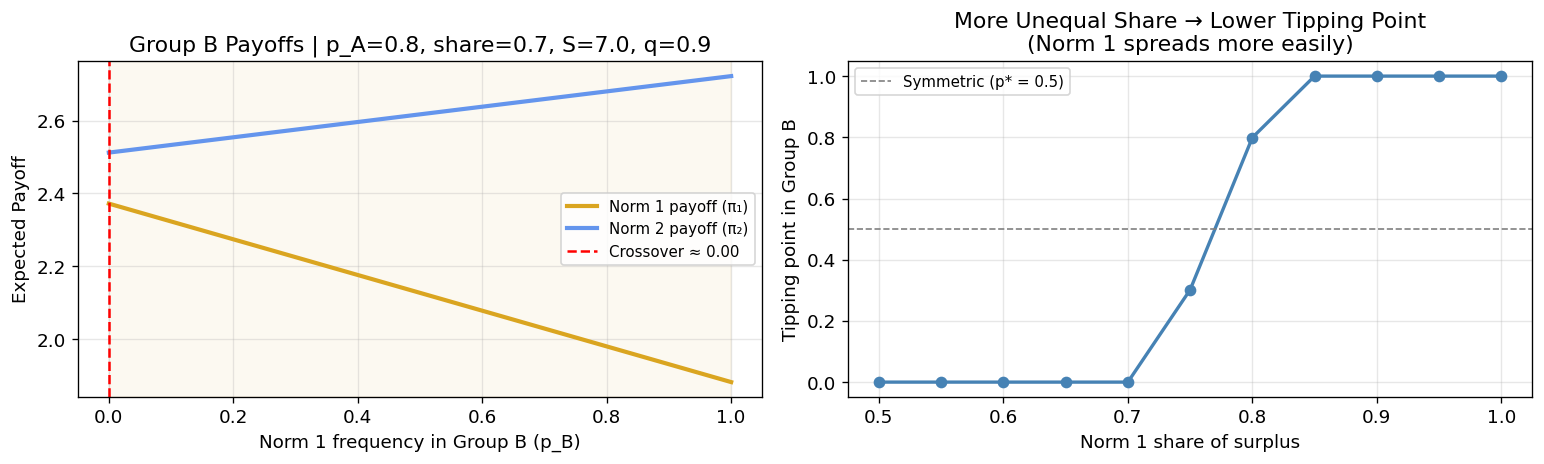

With norm1_share=0.7, S=7.0, p_A=0.8, q=0.9:
  Norm 1 favored in Group B above p_B ≈ 0.000
  pay_high = 4.90 | pay_low = 2.10


In [4]:
# ── Global parameters ──────────────────────────────────────────────────────────
surplus_benefit           = 7.0
norm1_share               = 0.7   # Norm 1 takes 70% of surplus
prob_outgroup_interaction  = 0.9   # high cross-group trade
p_A_fixed                 = 0.8   # Group A is mostly Norm 1
# ───────────────────────────────────────────────────────────────────────────────

# Local: sweep Group B's Norm 1 frequency
p_B_values = np.linspace(0, 1, 200)

q        = prob_outgroup_interaction
pay_high = norm1_share * surplus_benefit
pay_low  = (1 - norm1_share) * surplus_benefit

# Payoffs for Group B agents as a function of p_B
# p_in = p_B (own group), p_out = p_A_fixed (other group)
pi1_B = (q     * ((1 - p_A_fixed)  * (1 + pay_high) + p_A_fixed  * 1)
        + (1-q) * ((1 - p_B_values) * (1 + pay_high) + p_B_values * 1))

pi2_B = (q     * ((1 - p_A_fixed)  * 1 + p_A_fixed  * (1 + pay_low))
        + (1-q) * ((1 - p_B_values) * 1 + p_B_values * (1 + pay_low)))

# Find crossover point numerically
diff = pi1_B - pi2_B  # local
crossover_idx = np.argmin(np.abs(diff))  # local
crossover_p   = p_B_values[crossover_idx]  # local

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: payoff curves for Group B
ax = axes[0]
ax.plot(p_B_values, pi1_B, color='goldenrod',      linewidth=2.5, label='Norm 1 payoff (π₁)')
ax.plot(p_B_values, pi2_B, color='cornflowerblue', linewidth=2.5, label='Norm 2 payoff (π₂)')
ax.axvline(crossover_p, color='red', linestyle='--', linewidth=1.5,
           label=f'Crossover ≈ {crossover_p:.2f}')
ax.axvspan(0, crossover_p, alpha=0.06, color='cornflowerblue')
ax.axvspan(crossover_p, 1, alpha=0.06, color='goldenrod')
ax.set_xlabel('Norm 1 frequency in Group B (p_B)')
ax.set_ylabel('Expected Payoff')
ax.set_title(f'Group B Payoffs | p_A={p_A_fixed}, share={norm1_share}, S={surplus_benefit}, q={q}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: how crossover shifts with norm1_share
ax = axes[1]
share_values = np.arange(0.5, 1.01, 0.05)  # local: range of share values
crossovers   = []  # local: crossover point for each share

for share in share_values:
    ph = share * surplus_benefit
    pl = (1 - share) * surplus_benefit
    p1 = (q * ((1-p_A_fixed)*(1+ph) + p_A_fixed*1)
         + (1-q)*((1-p_B_values)*(1+ph) + p_B_values*1))
    p2 = (q * ((1-p_A_fixed)*1 + p_A_fixed*(1+pl))
         + (1-q)*((1-p_B_values)*1 + p_B_values*(1+pl)))
    d  = p1 - p2
    idx = np.argmin(np.abs(d))
    crossovers.append(p_B_values[idx])

ax.plot(share_values, crossovers, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Symmetric (p* = 0.5)')
ax.set_xlabel('Norm 1 share of surplus')
ax.set_ylabel('Tipping point in Group B')
ax.set_title('More Unequal Share → Lower Tipping Point\n(Norm 1 spreads more easily)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"With norm1_share={norm1_share}, S={surplus_benefit}, p_A={p_A_fixed}, q={q}:")
print(f"  Norm 1 favored in Group B above p_B ≈ {crossover_p:.3f}")
print(f"  pay_high = {pay_high:.2f} | pay_low = {pay_low:.2f}")

---
## 🔬 Experiment 1: Fair vs. Unfair Surplus Split — Single Runs

With a **fair split** (`norm1_share = 0.5`): both norms earn the same surplus from cross-norm interactions → no incentive for Norm 1 to spread → equilibrium depends on starting frequencies.

With an **unfair split** (`norm1_share > 0.5`): Norm 1 earns more → Norm 1 spreads through success-biased imitation → stratification emerges.

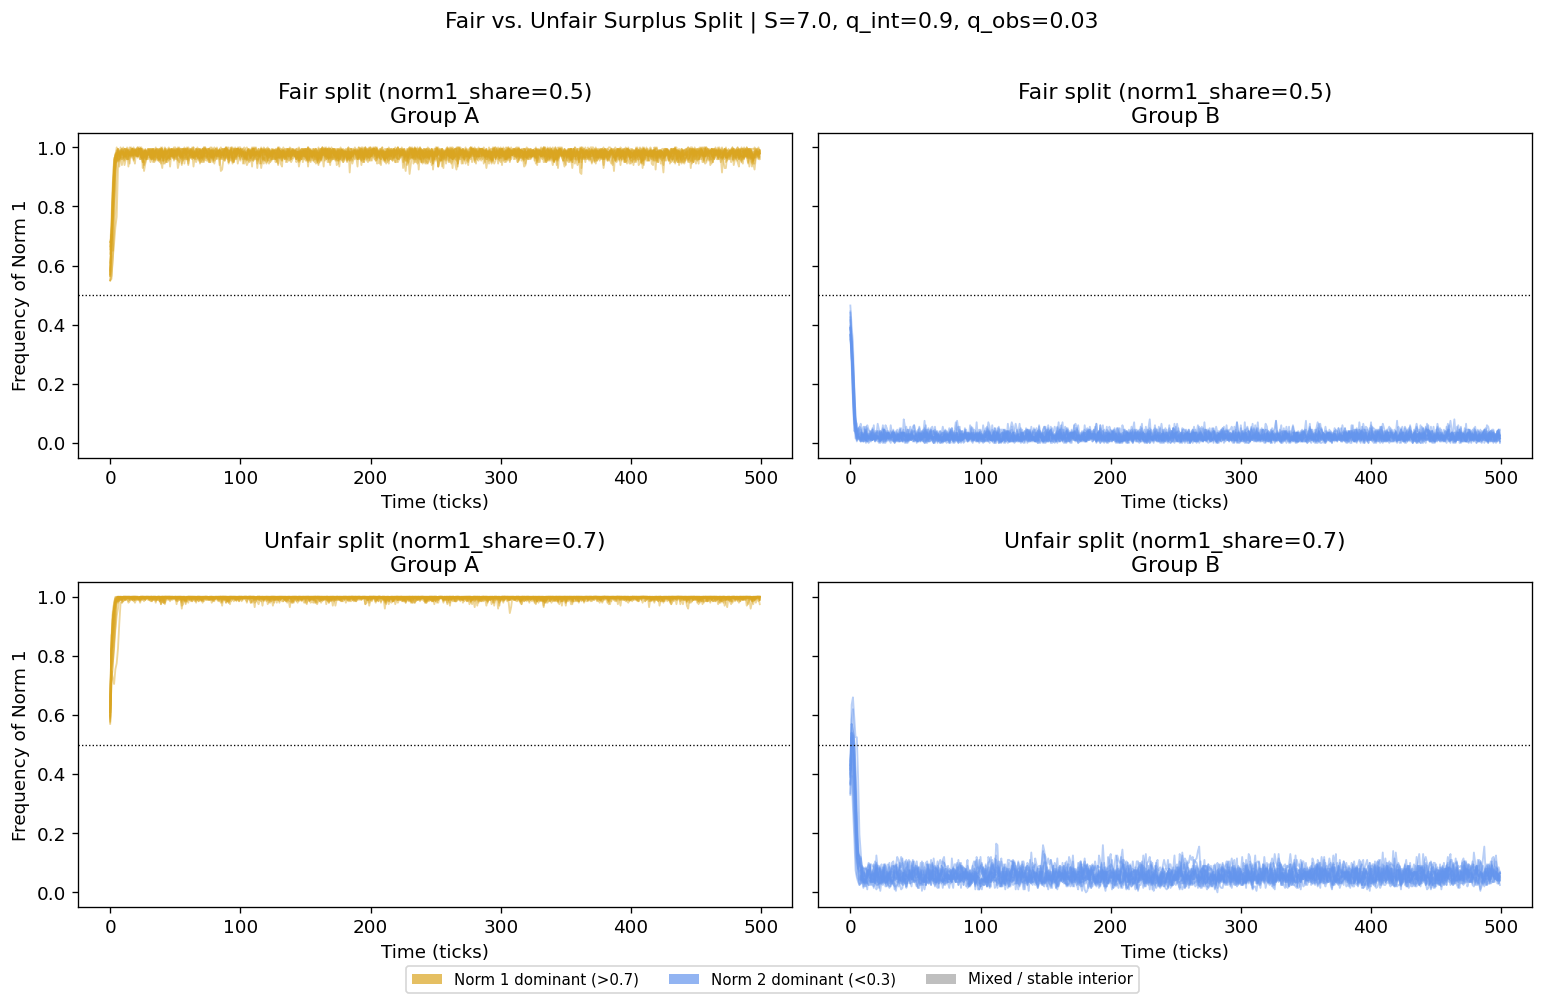

In [5]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                          = 400
init_norm1_A               = 0.60   # Group A: moderate Norm 1 majority
init_norm1_B               = 0.40   # Group B: moderate Norm 2 majority
surplus_benefit            = 7.0
prob_outgroup_interaction   = 0.90   # high economic cross-group contact
prob_outgroup_observation   = 0.03   # moderate imitation cross-group contact
max_ticks                  = 500
n_runs                     = 15
# ───────────────────────────────────────────────────────────────────────────────

share_scenarios = [
    (0.50, 'Fair split (norm1_share=0.5)'),
    (0.70, 'Unfair split (norm1_share=0.7)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)

for row, (share, title) in enumerate(share_scenarios):
    for col, (group_label, history_idx) in enumerate([('Group A', 0), ('Group B', 1)]):
        ax = axes[row, col]

        for _ in range(n_runs):
            hA, hB = run(N, init_norm1_A, init_norm1_B,
                         surplus_benefit, share,
                         prob_outgroup_interaction, prob_outgroup_observation,
                         max_ticks)
            h = hA if history_idx == 0 else hB
            # Color by final state: Norm 1 dominant (>0.7) = gold, Norm 2 dominant (<0.3) = blue, mixed = gray
            if h[-1] > 0.7:
                color = 'goldenrod'
            elif h[-1] < 0.3:
                color = 'cornflowerblue'
            else:
                color = 'gray'
            ax.plot(h, color=color, alpha=0.45, linewidth=1.1)

        ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel('Time (ticks)')
        ax.set_title(f'{title}\n{group_label}')
        if col == 0:
            ax.set_ylabel('Frequency of Norm 1')

legend_elements = [
    Patch(facecolor='goldenrod',      alpha=0.7, label='Norm 1 dominant (>0.7)'),
    Patch(facecolor='cornflowerblue', alpha=0.7, label='Norm 2 dominant (<0.3)'),
    Patch(facecolor='gray',           alpha=0.5, label='Mixed / stable interior'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f'Fair vs. Unfair Surplus Split | S={surplus_benefit}, q_int={prob_outgroup_interaction}, q_obs={prob_outgroup_observation}',
             y=1.01)
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 2: Sweep norm1_share — When Does Stratification Emerge?

This mirrors the `experimentunfair` batch in the NetLogo code.

We hold everything fixed and vary `norm1_share` from 0.5 (fair) to 1.0 (extreme). We measure whether Norm 1 spreads to domination in both groups — the signature of stratification.

In [6]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                          = 400
init_norm1_A               = 0.60
init_norm1_B               = 0.40
surplus_benefit            = 3.0    # lower surplus, as in NetLogo's experimentunfair
prob_outgroup_interaction   = 0.80
prob_outgroup_observation   = 0.03
max_ticks                  = 200
n_reps                     = 50

share_values = np.arange(0.50, 1.01, 0.025)  # 0.5, 0.525, ..., 1.0
# ───────────────────────────────────────────────────────────────────────────────

# Track fraction of runs where Norm 1 dominates (>0.8) in each group by end
norm1_dom_A = []  # global result: Group A
norm1_dom_B = []  # global result: Group B

for share in share_values:
    dom_A = 0  # local counter
    dom_B = 0  # local counter
    for _ in range(n_reps):
        hA, hB = run(N, init_norm1_A, init_norm1_B,
                     surplus_benefit, share,
                     prob_outgroup_interaction, prob_outgroup_observation,
                     max_ticks)
        if hA[-1] > 0.8: dom_A += 1
        if hB[-1] > 0.8: dom_B += 1
    norm1_dom_A.append(dom_A / n_reps)
    norm1_dom_B.append(dom_B / n_reps)
    print(f"  share={share:.3f} | A dom: {dom_A}/{n_reps} | B dom: {dom_B}/{n_reps}", flush=True)

print("\nDone!")

  share=0.500 | A dom: 50/50 | B dom: 0/50
  share=0.525 | A dom: 50/50 | B dom: 0/50
  share=0.550 | A dom: 50/50 | B dom: 0/50
  share=0.575 | A dom: 48/50 | B dom: 2/50
  share=0.600 | A dom: 50/50 | B dom: 0/50
  share=0.625 | A dom: 49/50 | B dom: 1/50
  share=0.650 | A dom: 49/50 | B dom: 1/50
  share=0.675 | A dom: 49/50 | B dom: 1/50
  share=0.700 | A dom: 48/50 | B dom: 2/50
  share=0.725 | A dom: 50/50 | B dom: 0/50
  share=0.750 | A dom: 48/50 | B dom: 2/50
  share=0.775 | A dom: 49/50 | B dom: 1/50
  share=0.800 | A dom: 46/50 | B dom: 4/50
  share=0.825 | A dom: 49/50 | B dom: 1/50
  share=0.850 | A dom: 47/50 | B dom: 4/50
  share=0.875 | A dom: 46/50 | B dom: 5/50
  share=0.900 | A dom: 42/50 | B dom: 20/50
  share=0.925 | A dom: 44/50 | B dom: 36/50
  share=0.950 | A dom: 49/50 | B dom: 50/50
  share=0.975 | A dom: 50/50 | B dom: 50/50
  share=1.000 | A dom: 50/50 | B dom: 50/50

Done!


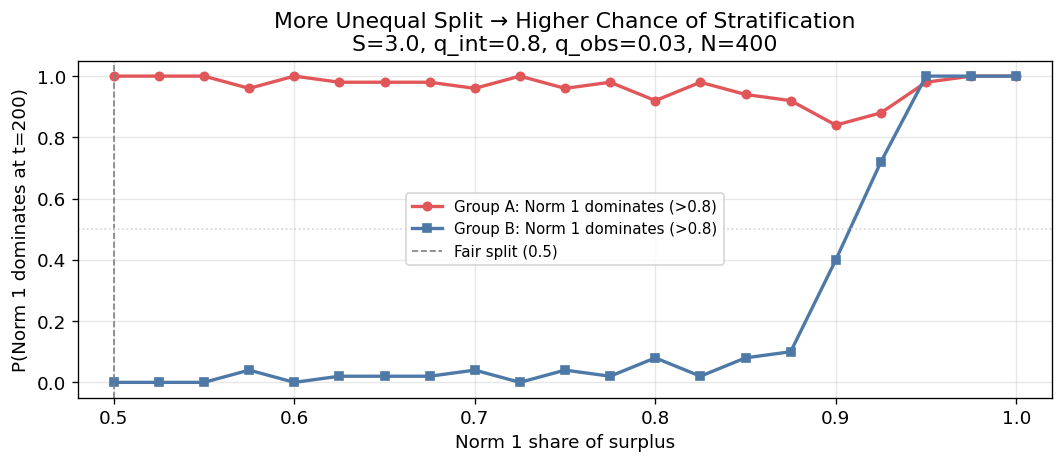

Key insight: Group A (which starts with more Norm 1) stratifies first.
Group B eventually follows via cross-group observation, but lags behind.


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(share_values, norm1_dom_A, 'o-', color='#e15759', linewidth=2,
        markersize=5, label='Group A: Norm 1 dominates (>0.8)')
ax.plot(share_values, norm1_dom_B, 's-', color='#4e79a7', linewidth=2,
        markersize=5, label='Group B: Norm 1 dominates (>0.8)')

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Fair split (0.5)')
ax.axhline(0.5, color='lightgray', linestyle=':', linewidth=1)

ax.set_xlabel('Norm 1 share of surplus')
ax.set_ylabel('P(Norm 1 dominates at t=200)')
ax.set_title(
    f'More Unequal Split → Higher Chance of Stratification\n'
    f'S={surplus_benefit}, q_int={prob_outgroup_interaction}, q_obs={prob_outgroup_observation}, N={N}'
)
ax.set_xlim(0.48, 1.02)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight: Group A (which starts with more Norm 1) stratifies first.")
print("Group B eventually follows via cross-group observation, but lags behind.")

---
## 🔬 Experiment 3: The Fair Equilibrium — Effect of Cross-Group Interaction Rate

This mirrors `experimentfair` in the NetLogo batch experiments.

With a fair split (`norm1_share = 0.5`), no stratification should emerge — but the degree of cross-group economic interaction (`prob_outgroup_interaction`) still affects which norm equilibrium the system settles into.

When groups interact mostly with each other (high `prob_outgroup_interaction`), the cross-group norm frequencies matter more for payoffs. This can either stabilize or destabilize the current distribution.

In [8]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                          = 400
init_norm1_A               = 0.60
init_norm1_B               = 0.40
surplus_benefit            = 3.0
norm1_share                = 0.50   # FAIR split
prob_outgroup_observation   = 0.03
max_ticks                  = 200
n_reps                     = 50

# Sweep cross-group interaction rate (economic contact)
qint_values = np.arange(0.40, 0.91, 0.02)
# ───────────────────────────────────────────────────────────────────────────────

# Final mean Norm 1 freq in each group across runs
mean_norm1_A = []  # global result
mean_norm1_B = []  # global result

for q_int in qint_values:
    finals_A = []  # local: final freq across reps for Group A
    finals_B = []  # local: final freq across reps for Group B
    for _ in range(n_reps):
        hA, hB = run(N, init_norm1_A, init_norm1_B,
                     surplus_benefit, norm1_share,
                     q_int, prob_outgroup_observation,
                     max_ticks)
        finals_A.append(hA[-1])
        finals_B.append(hB[-1])
    mean_norm1_A.append(np.mean(finals_A))
    mean_norm1_B.append(np.mean(finals_B))
    print(f"  q_int={q_int:.2f} | mean Norm1 A={np.mean(finals_A):.3f} | B={np.mean(finals_B):.3f}",
          flush=True)

print("\nDone!")

  q_int=0.40 | mean Norm1 A=0.499 | B=0.495
  q_int=0.42 | mean Norm1 A=0.509 | B=0.504
  q_int=0.44 | mean Norm1 A=0.505 | B=0.510
  q_int=0.46 | mean Norm1 A=0.509 | B=0.491
  q_int=0.48 | mean Norm1 A=0.488 | B=0.510
  q_int=0.50 | mean Norm1 A=0.513 | B=0.506
  q_int=0.52 | mean Norm1 A=0.519 | B=0.476
  q_int=0.54 | mean Norm1 A=0.506 | B=0.483
  q_int=0.56 | mean Norm1 A=0.570 | B=0.409
  q_int=0.58 | mean Norm1 A=0.702 | B=0.290
  q_int=0.60 | mean Norm1 A=0.782 | B=0.229
  q_int=0.62 | mean Norm1 A=0.766 | B=0.224
  q_int=0.64 | mean Norm1 A=0.789 | B=0.208
  q_int=0.66 | mean Norm1 A=0.822 | B=0.175
  q_int=0.68 | mean Norm1 A=0.907 | B=0.102
  q_int=0.70 | mean Norm1 A=0.934 | B=0.061
  q_int=0.72 | mean Norm1 A=0.902 | B=0.094
  q_int=0.74 | mean Norm1 A=0.910 | B=0.090
  q_int=0.76 | mean Norm1 A=0.932 | B=0.073
  q_int=0.78 | mean Norm1 A=0.934 | B=0.063
  q_int=0.80 | mean Norm1 A=0.916 | B=0.081
  q_int=0.82 | mean Norm1 A=0.957 | B=0.036
  q_int=0.84 | mean Norm1 A=0.96

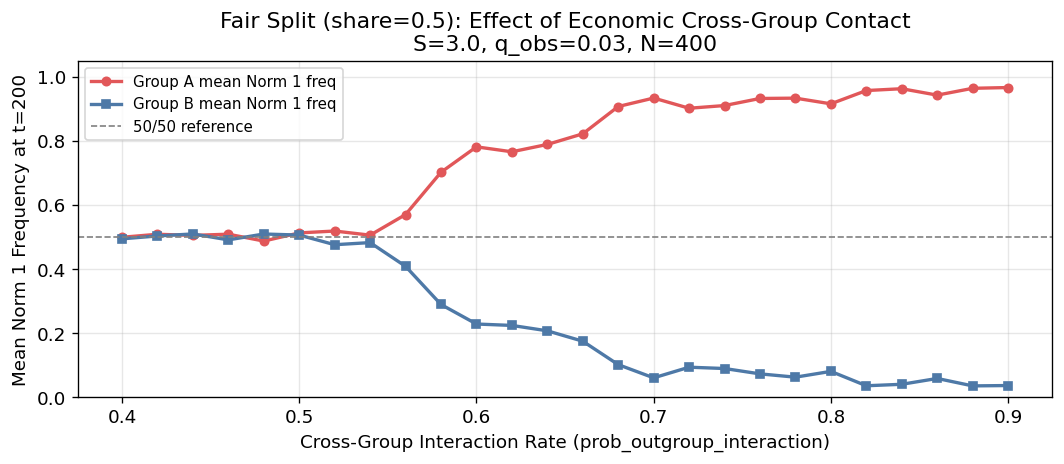

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(qint_values, mean_norm1_A, 'o-', color='#e15759', linewidth=2,
        markersize=5, label='Group A mean Norm 1 freq')
ax.plot(qint_values, mean_norm1_B, 's-', color='#4e79a7', linewidth=2,
        markersize=5, label='Group B mean Norm 1 freq')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50/50 reference')

ax.set_xlabel('Cross-Group Interaction Rate (prob_outgroup_interaction)')
ax.set_ylabel('Mean Norm 1 Frequency at t=200')
ax.set_title(
    f'Fair Split (share=0.5): Effect of Economic Cross-Group Contact\n'
    f'S={surplus_benefit}, q_obs={prob_outgroup_observation}, N={N}'
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 4: Joint Effect of Share and Interaction Rate

The two main parameters — how unfair the split is and how much groups interact economically — work together to drive stratification. Let's map them jointly.

In [10]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                          = 400
init_norm1_A               = 0.60
init_norm1_B               = 0.40
surplus_benefit            = 3.0
prob_outgroup_observation   = 0.03
max_ticks                  = 200
n_reps                     = 30    # lower for heatmap speed

share_grid = np.arange(0.50, 1.01, 0.05)       # norm1_share axis
qint_grid  = np.arange(0.40, 0.91, 0.05)       # prob_outgroup_interaction axis
# ───────────────────────────────────────────────────────────────────────────────

# Build heatmap: rows = q_int, cols = share
# Value = mean final Norm 1 freq in Group B (the lagging group)
heatmap_B = np.zeros((len(qint_grid), len(share_grid)))

for i, q_int in enumerate(qint_grid):
    for j, share in enumerate(share_grid):
        finals_B = []  # local
        for _ in range(n_reps):
            _, hB = run(N, init_norm1_A, init_norm1_B,
                        surplus_benefit, share,
                        q_int, prob_outgroup_observation,
                        max_ticks)
            finals_B.append(hB[-1])
        heatmap_B[i, j] = np.mean(finals_B)
    print(f"  q_int={q_int:.2f} done", flush=True)

print("\nDone!")

  q_int=0.40 done
  q_int=0.45 done
  q_int=0.50 done
  q_int=0.55 done
  q_int=0.60 done
  q_int=0.65 done
  q_int=0.70 done
  q_int=0.75 done
  q_int=0.80 done
  q_int=0.85 done
  q_int=0.90 done

Done!


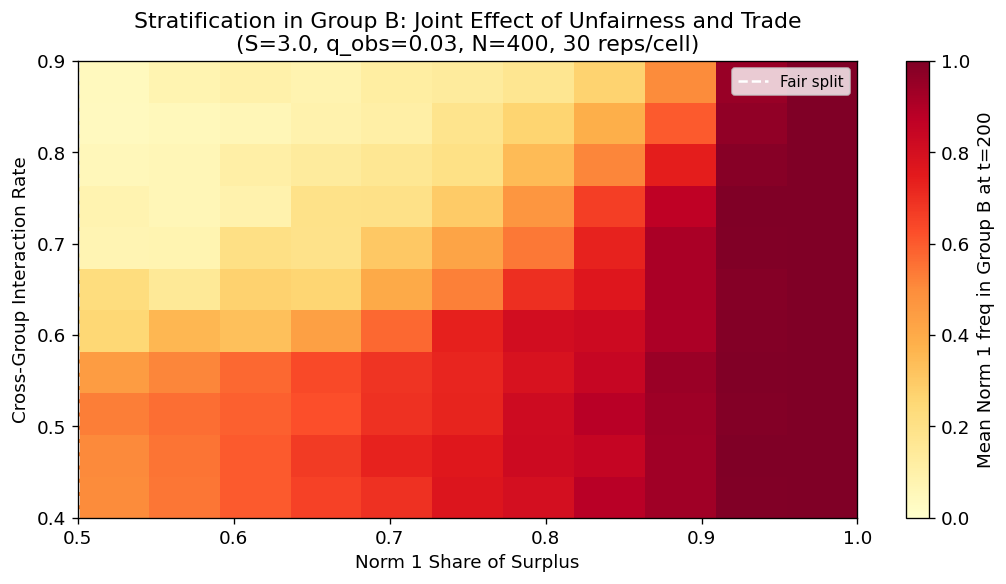

Dark red = Norm 1 dominates Group B (stratification)
Yellow/white = Norm 2 holds or mixed equilibrium
Both high share AND high inter-group trade are needed for full stratification.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(heatmap_B, origin='lower', aspect='auto',
               extent=[share_grid[0], share_grid[-1],
                       qint_grid[0],  qint_grid[-1]],
               cmap='YlOrRd', vmin=0, vmax=1)

plt.colorbar(im, ax=ax, label='Mean Norm 1 freq in Group B at t=200')
ax.axvline(0.5, color='white', linestyle='--', linewidth=1.5, label='Fair split')
ax.set_xlabel('Norm 1 Share of Surplus')
ax.set_ylabel('Cross-Group Interaction Rate')
ax.set_title(
    'Stratification in Group B: Joint Effect of Unfairness and Trade\n'
    f'(S={surplus_benefit}, q_obs={prob_outgroup_observation}, N={N}, {n_reps} reps/cell)'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Dark red = Norm 1 dominates Group B (stratification)")
print("Yellow/white = Norm 2 holds or mixed equilibrium")
print("Both high share AND high inter-group trade are needed for full stratification.")

---
## 🔬 Experiment 5: The Paradox — Why Would Group B Adopt a Losing Norm?

The most counterintuitive result: Group B agents, whose Norm 2 gives them the *low* share, nonetheless copy Norm 1 from Group A — and end up in a world where everyone is Norm 1 and **no surplus is produced at all** (since surplus only occurs in mixed Norm 1 / Norm 2 pairs).

This is the **tragedy of stratification**: rational imitation of successful models leads the population to a worse collective outcome.

Let's track the **total surplus produced** per tick to make this visible.

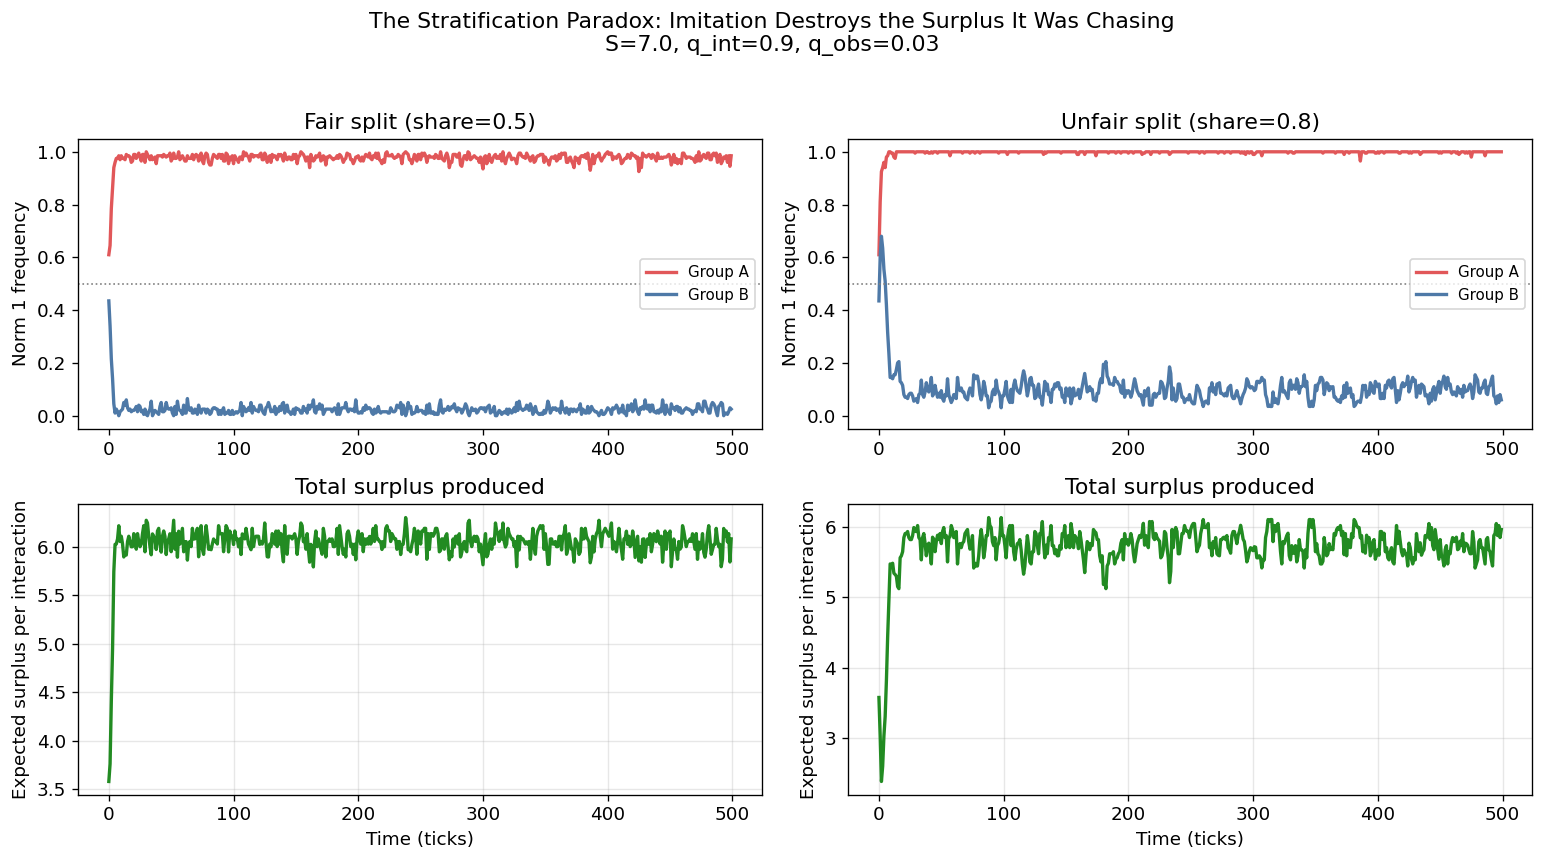

With unfair split: Norm 1 spreads to everyone → no more Norm 2 partners → surplus collapses.
This is the tragedy of stratification: individually rational copying is collectively harmful.


In [12]:
def run_with_surplus_tracking(N, init_norm1_A, init_norm1_B,
                               surplus_benefit, norm1_share,
                               prob_outgroup_interaction, prob_outgroup_observation,
                               max_ticks=500):
    """
    Same as run(), but also tracks the expected total surplus produced per tick.

    Total surplus is maximized when half the population is Norm 1 and half is Norm 2
    (every interaction is a mixed pair). It goes to zero when everyone holds the same norm.

    Returns:
    --------
    history_A       : list of float — Norm 1 freq in Group A
    history_B       : list of float — Norm 1 freq in Group B
    surplus_history : list of float — expected total surplus produced each tick
    """

    agents    = setup(N, init_norm1_A, init_norm1_B)
    n_per_grp = N // 2

    history_A       = []
    history_B       = []
    surplus_history = []  # global tracking: total surplus

    q = prob_outgroup_interaction

    for tick in range(max_ticks):

        n1_A = sum(1 for a in agents if a.group == 0 and a.norm == 1)  # local
        n1_B = sum(1 for a in agents if a.group == 1 and a.norm == 1)  # local
        p_A  = n1_A / n_per_grp  # local
        p_B  = n1_B / n_per_grp  # local

        history_A.append(p_A)
        history_B.append(p_B)

        # Expected surplus produced per interaction:
        # A mixed pair (Norm1 + Norm2) produces surplus_benefit.
        # Same-norm pairs produce 0 extra surplus.
        # Probability of a mixed pair depends on group interaction structure.
        # For simplicity: compute expected fraction of cross-norm interactions
        # within group and between groups.
        # Mixed pair prob (within A) = p_A*(1-p_A) + (1-p_A)*p_A = 2*p_A*(1-p_A)
        # Mixed pair prob (within B) = 2*p_B*(1-p_B)
        # Mixed pair prob (across)   = p_A*(1-p_B) + (1-p_A)*p_B
        within_A_mixed  = 2 * p_A * (1 - p_A)                     # local
        within_B_mixed  = 2 * p_B * (1 - p_B)                     # local
        cross_mixed     = p_A * (1 - p_B) + (1 - p_A) * p_B       # local

        # Total expected surplus (normalized by N so it's per agent per tick)
        total_surplus = surplus_benefit * (
            (1 - q) * (within_A_mixed + within_B_mixed) / 2
            + q * cross_mixed
        )
        surplus_history.append(total_surplus)

        calculate_payoffs(agents, surplus_benefit, norm1_share, prob_outgroup_interaction)
        evolve(agents, prob_outgroup_observation)

    return history_A, history_B, surplus_history


# ── Run two scenarios: fair and unfair ────────────────────────────────────────
N                          = 400
init_norm1_A               = 0.60
init_norm1_B               = 0.40
surplus_benefit            = 7.0
prob_outgroup_interaction   = 0.90
prob_outgroup_observation   = 0.03
max_ticks                  = 500

random.seed(12)
hA_fair, hB_fair, surp_fair = run_with_surplus_tracking(
    N, init_norm1_A, init_norm1_B,
    surplus_benefit, norm1_share=0.50,
    prob_outgroup_interaction=prob_outgroup_interaction,
    prob_outgroup_observation=prob_outgroup_observation,
    max_ticks=max_ticks
)

random.seed(12)
hA_unfair, hB_unfair, surp_unfair = run_with_surplus_tracking(
    N, init_norm1_A, init_norm1_B,
    surplus_benefit, norm1_share=0.80,
    prob_outgroup_interaction=prob_outgroup_interaction,
    prob_outgroup_observation=prob_outgroup_observation,
    max_ticks=max_ticks
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for col, (label, hA, hB, surp) in enumerate([
    ('Fair split (share=0.5)', hA_fair, hB_fair, surp_fair),
    ('Unfair split (share=0.8)', hA_unfair, hB_unfair, surp_unfair),
]):
    # Top row: norm frequencies
    ax = axes[0, col]
    ax.plot(hA, color='#e15759', linewidth=2, label='Group A')
    ax.plot(hB, color='#4e79a7', linewidth=2, label='Group B')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_ylabel('Norm 1 frequency')
    ax.set_title(label)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)

    # Bottom row: total surplus over time
    ax = axes[1, col]
    ax.plot(surp, color='forestgreen', linewidth=2)
    ax.set_xlabel('Time (ticks)')
    ax.set_ylabel('Expected surplus per interaction')
    ax.set_title('Total surplus produced')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'The Stratification Paradox: Imitation Destroys the Surplus It Was Chasing\n'
    f'S={surplus_benefit}, q_int={prob_outgroup_interaction}, q_obs={prob_outgroup_observation}',
    y=1.02
)
plt.tight_layout()
plt.show()

print("With unfair split: Norm 1 spreads to everyone → no more Norm 2 partners → surplus collapses.")
print("This is the tragedy of stratification: individually rational copying is collectively harmful.")

---

## 📝 Conceptual Summary

| Concept | What It Means In This Model |
|---|---|
| **Division of labor** | Surplus is produced only when two *different-norm* agents interact — specialization requires complementarity |
| **Surplus sharing norm** | Norm 1 = claim the high share; Norm 2 = accept the low share |
| **`norm1_share`** | Controls fairness: 0.5 = equal split, 1.0 = Norm 1 takes everything |
| **`prob_outgroup_interaction`** | Who you *trade with* — affects payoffs |
| **`prob_outgroup_observation`** | Who you *copy* — affects norm evolution |
| **Why Norm 1 spreads** | Norm 1 holders earn more → Norm 2 holders copy Norm 1 via success-biased imitation |
| **The paradox** | As Norm 1 spreads, fewer Norm 2 agents exist to generate surplus with → payoffs fall → but copying still drives Norm 1 to fixation |
| **The tragedy** | A collectively worse outcome (everyone Norm 1 = no surplus) is reached through individually rational behavior |
| **Henrich & Boyd insight** | Stratifying norms (unequal division of labor) can spread and stabilize through cultural evolution even when they reduce group welfare |

---

## 🔗 How All Four Chapter 7 Models Connect

| Model | Core question | Payoff from matching? | Groups? | Key result |
|---|---|---|---|---|
| **Simple** | Which norm wins with symmetric incentives? | Yes — match others | No | Stochastic fixation; p* = 0.5 |
| **Asymmetric** | Can a prosocially better but rare-costly norm survive? | Yes — but asymmetric costs | No | Tipping point p* = cr/(cr+bc); lock-in |
| **Two Groups** | Can a norm established in one group spread to another? | Yes — asymmetric | Yes | Cross-group observation imports norm; bp drives diffusion |
| **Division of Labor** | Can a stratifying norm spread even if it harms the group? | No — complementary, not matching | Yes | Stratification through imitation; surplus tragedy |